In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

#ddw function which loads us correct .rec and .mrc files
from ddw.utils.mrctools import load_mrc_data

# Checking the file PATH
print(os.getcwd())
print(os.path.exists("./tutorial/tutorial_data/tomo_all_frames.rec"))
print(os.path.exists("./tutorial/tutorial_project/refined_tomograms/tomo_even_frames+tomo_odd_frames_refined.rec"))

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\notebooks
True
True


In [2]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)


def compute_log_power_xz_slice_memory_efficient(vol, eps=1e-8):
    """
    Compute central XZ Fourier log-power slice without creating full 3D FFT volume.

    For volume shape (z, y, x), the ky=0 slice of the 3D FFT is equivalent
    to the 2D FFT of the projection summed over y.
    """
    vol = np.asarray(vol, dtype=np.float32)

    # remove DC bias
    vol = vol - np.mean(vol, dtype=np.float32)

    # ky=0 Fourier slice via projection over y
    proj_xz = np.sum(vol, axis=1, dtype=np.float32)  # shape: (z, x)

    F_xz = np.fft.fftshift(np.fft.fft2(proj_xz))
    log_power_xz = np.log1p(np.abs(F_xz) ** 2 + eps).astype(np.float32)

    return log_power_xz

In [3]:
# Input / baseline tomogram from filtered back-projection
tomo_input_path = Path("./tutorial/tutorial_data/tomo_all_frames.rec")

# DeepDeWedge refined tomogram from Step 3
tomo_refined_path = Path("./tutorial/tutorial_project/refined_tomograms/tomo_even_frames+tomo_odd_frames_refined.rec")

tomo_input = load_volume(tomo_input_path)
tomo_refined = load_volume(tomo_refined_path)

print(type(tomo_input), tomo_input.shape)
print(type(tomo_refined), tomo_refined.shape)

<class 'numpy.ndarray'> (209, 1280, 550)
<class 'numpy.ndarray'> (209, 1280, 550)


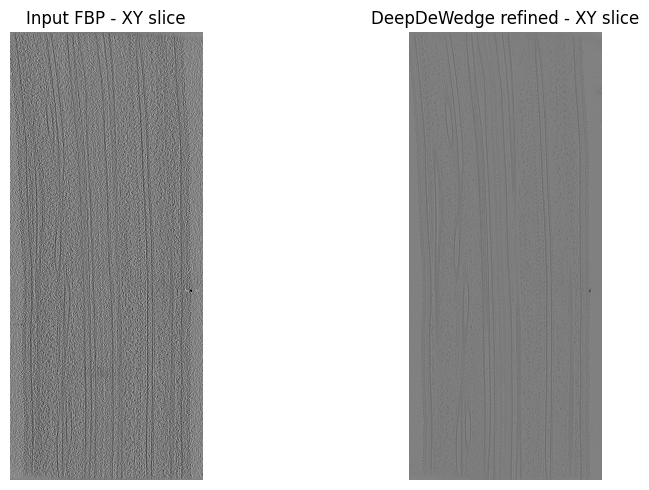

In [4]:
z_mid = tomo_input.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

vmin = -3 * tomo_input.std()
vmax =  3 * tomo_input.std()

axes[0].imshow(tomo_input[z_mid, :, :], cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Input FBP - XY slice")
axes[0].axis("off")

axes[1].imshow(tomo_refined[z_mid, :, :], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("DeepDeWedge refined - XY slice")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Power Spectrum Analysis

In [5]:
#Transforms the whole volume to Fourier space
''''
def compute_power_spectrum(volume):
    """
    Compute centered 3D power spectrum of a real-space volume.

    Input:
        volume: 3D numpy array, shape usually (z, y, x)

    Output:
        power: 3D numpy array, same shape, centered Fourier power spectrum
    """
    # 3D Fourier transform
    fft_volume = np.fft.fftn(volume)

    # Shift zero frequency to the center for visualization
    fft_volume_shifted = np.fft.fftshift(fft_volume)

    # Power spectrum = squared magnitude of Fourier coefficients
    power = np.abs(fft_volume_shifted) ** 2

    return power


power_input = compute_power_spectrum(tomo_input)
power_refined = compute_power_spectrum(tomo_refined)

print(power_input.shape)
print(power_refined.shape)
'''

'\'\ndef compute_power_spectrum(volume):\n    """\n    Compute centered 3D power spectrum of a real-space volume.\n\n    Input:\n        volume: 3D numpy array, shape usually (z, y, x)\n\n    Output:\n        power: 3D numpy array, same shape, centered Fourier power spectrum\n    """\n    # 3D Fourier transform\n    fft_volume = np.fft.fftn(volume)\n\n    # Shift zero frequency to the center for visualization\n    fft_volume_shifted = np.fft.fftshift(fft_volume)\n\n    # Power spectrum = squared magnitude of Fourier coefficients\n    power = np.abs(fft_volume_shifted) ** 2\n\n    return power\n\n\npower_input = compute_power_spectrum(tomo_input)\npower_refined = compute_power_spectrum(tomo_refined)\n\nprint(power_input.shape)\nprint(power_refined.shape)\n'

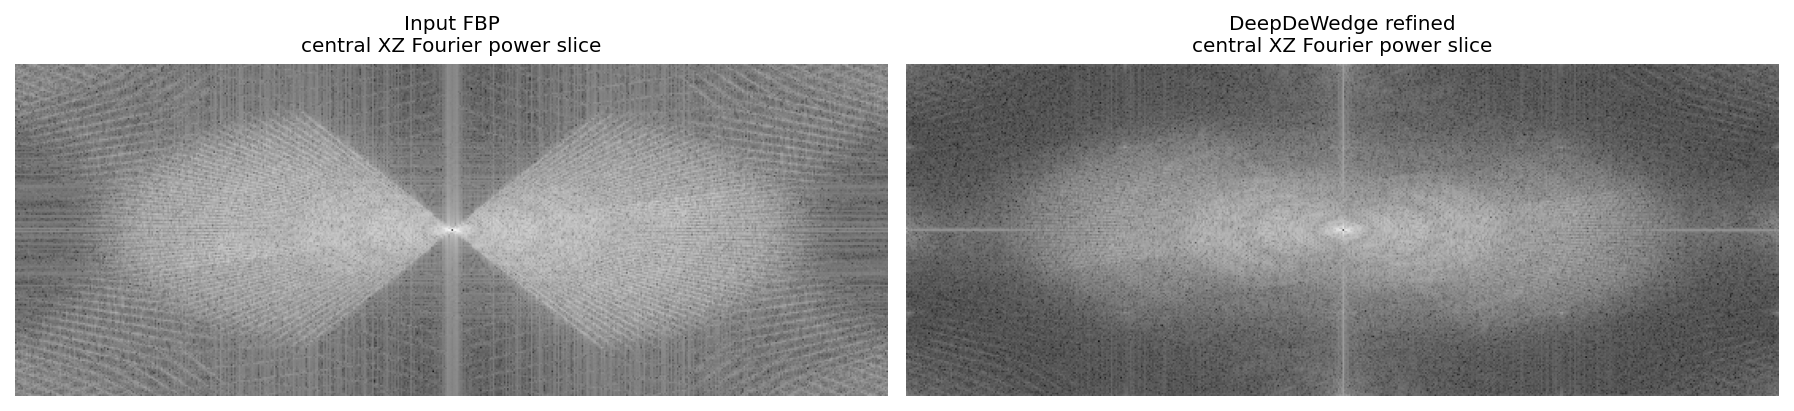

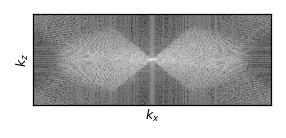

In [12]:
log_power_input_xz = compute_log_power_xz_slice_memory_efficient(tomo_input)
log_power_refined_xz = compute_log_power_xz_slice_memory_efficient(tomo_refined)

# Use same contrast range for fair comparison
vmin = min(log_power_input_xz.min(), log_power_refined_xz.min())
vmax = max(log_power_input_xz.max(), log_power_refined_xz.max())


#------------------
# Combined plot
#------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(log_power_input_xz, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Input FBP\ncentral XZ Fourier power slice")
axes[0].axis("off")

axes[1].imshow(log_power_refined_xz, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("DeepDeWedge refined\ncentral XZ Fourier power slice")
axes[1].axis("off")


os.makedirs("../figures", exist_ok=True)
save_path = "../figures/FBP_DDW_Fourier_Power_Slice.png"

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

#------------------
# Single Plot
#------------------

# Compute central XZ Fourier power slice for input FBP
log_power_input_xz = compute_log_power_xz_slice_memory_efficient(tomo_input)

# ------------------
# Report-style single plot
# ------------------


plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

cm = 1 / 2.54

fig, ax = plt.subplots(figsize=(5.2 * cm, 5.2 * cm))

ax.imshow(
    log_power_input_xz,
    cmap="gray",
    origin="lower",
    interpolation="nearest"
)

ax.set_aspect("equal")

# Minimal Fourier-space axes
ax.set_xlabel(r"$k_x$", labelpad=1)
ax.set_ylabel(r"$k_z$", labelpad=1)

# No numerical ticks for a clean schematic/report figure
ax.set_xticks([])
ax.set_yticks([])

# Thin frame
for spine in ax.spines.values():
    spine.set_linewidth(0.6)

os.makedirs("../figures", exist_ok=True)

save_path_pdf = "../figures/FBP_Fourier_Power_XZ_report.pdf"
save_path_png = "../figures/FBP_Fourier_Power_XZ_report.png"

fig.savefig(save_path_pdf, bbox_inches="tight")
fig.savefig(save_path_png, dpi=300, bbox_inches="tight")

plt.show()

In [7]:
#Fourier Shell Correlation
def compute_fsc(vol1, vol2, num_shells=None):
    """
    Compute Fourier Shell Correlation between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        3D volumes with the same shape, usually ordered as (z, y, x).
    num_shells : int or None
        Number of radial Fourier shells. If None, use half the smallest dimension.

    Returns
    -------
    shell_frequencies : np.ndarray
        Normalized shell frequencies from low to high frequency.
    fsc_values : np.ndarray
        FSC values for each shell.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape."

    # Fourier transform and shift zero frequency to center
    F1 = np.fft.fftshift(np.fft.fftn(vol1))
    F2 = np.fft.fftshift(np.fft.fftn(vol2))

    shape = vol1.shape

    if num_shells is None:
        num_shells = min(shape) // 2

    # Create coordinate grid in Fourier space
    z, y, x = np.indices(shape)
    center = np.array(shape) // 2

    # Radial distance from Fourier center
    r = np.sqrt(
        (z - center[0])**2 +
        (y - center[1])**2 +
        (x - center[2])**2
    )

    r_max = min(shape) // 2
    shell_edges = np.linspace(0, r_max, num_shells + 1)

    shell_frequencies = []
    fsc_values = []

    for i in range(num_shells):
        shell_mask = (r >= shell_edges[i]) & (r < shell_edges[i + 1])

        if np.sum(shell_mask) == 0:
            shell_frequencies.append(np.nan)
            fsc_values.append(np.nan)
            continue

        F1_shell = F1[shell_mask]
        F2_shell = F2[shell_mask]

        numerator = np.sum(F1_shell * np.conj(F2_shell))
        denominator = np.sqrt(
            np.sum(np.abs(F1_shell)**2) *
            np.sum(np.abs(F2_shell)**2)
        )

        if denominator == 0:
            fsc = np.nan
        else:
            fsc = np.real(numerator / denominator)

        shell_center = 0.5 * (shell_edges[i] + shell_edges[i + 1])
        normalized_frequency = shell_center / r_max

        shell_frequencies.append(normalized_frequency)
        fsc_values.append(fsc)

    return np.array(shell_frequencies), np.array(fsc_values)

In [9]:
tomo_even = load_volume("./tutorial/tutorial_data/tomo_even_frames.rec")
tomo_odd = load_volume("./tutorial/tutorial_data/tomo_odd_frames.rec")

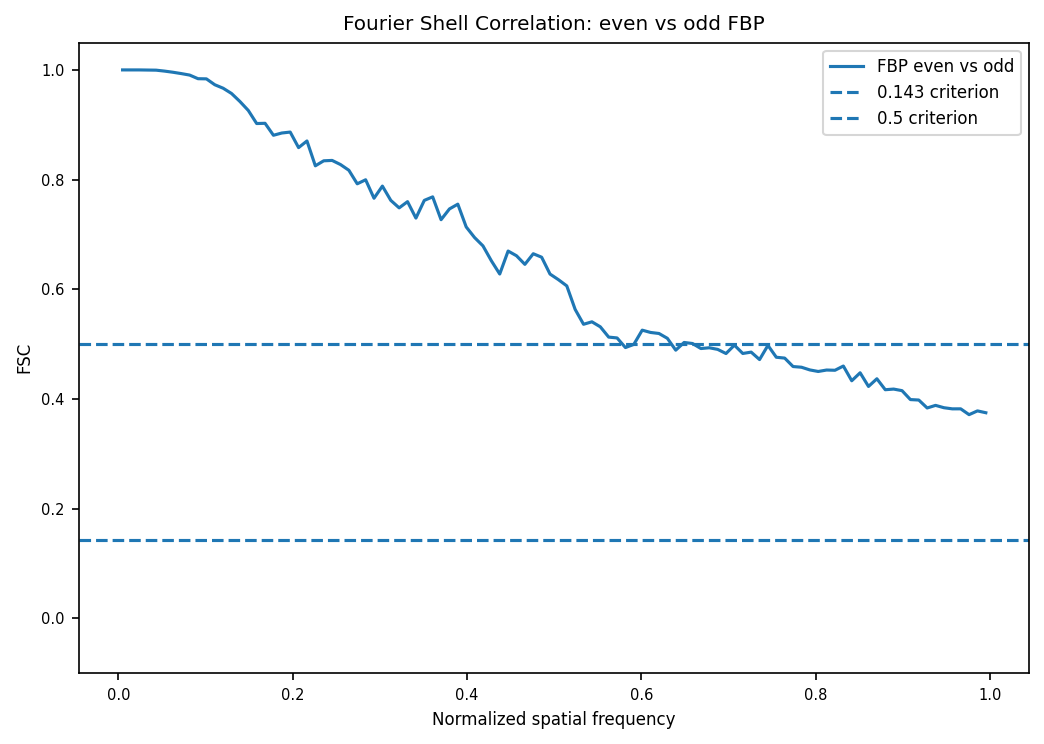

Saved to: C:\Users\chris\Desktop\Fabio\figures\day5_fsc_even_odd_fbp.png
File exists: True


In [10]:
freqs, fsc_values = compute_fsc(tomo_even, tomo_odd)

plt.figure(figsize=(7, 5))
plt.plot(freqs, fsc_values, label="FBP even vs odd")
plt.axhline(0.143, linestyle="--", label="0.143 criterion")
plt.axhline(0.5, linestyle="--", label="0.5 criterion")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("Fourier Shell Correlation: even vs odd FBP")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.tight_layout()

os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/day5_fsc_even_odd_fbp.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", os.path.abspath(save_path))
print("File exists:", os.path.exists(save_path))

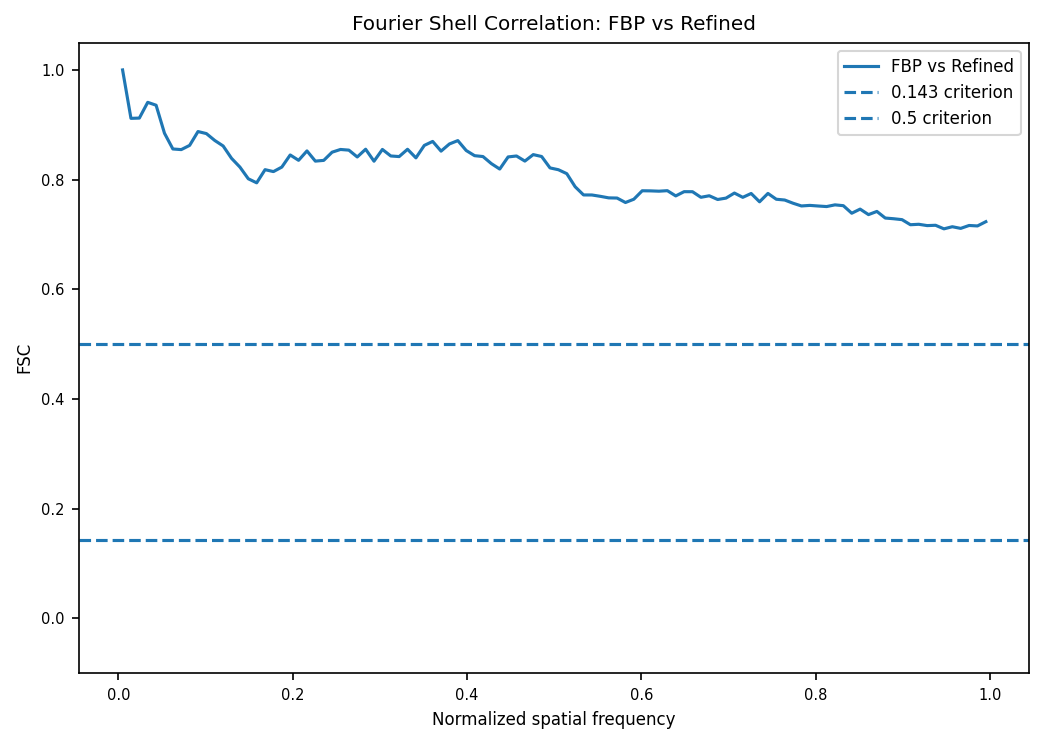

In [11]:
freqs, fsc_values = compute_fsc(tomo_input, tomo_refined)

plt.figure(figsize=(7, 5))
plt.plot(freqs, fsc_values, label="FBP vs Refined")
plt.axhline(0.143, linestyle="--", label="0.143 criterion")
plt.axhline(0.5, linestyle="--", label="0.5 criterion")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("Fourier Shell Correlation: FBP vs Refined")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.tight_layout()

#os.makedirs("../../figures", exist_ok=True)
#save_path = "../../figures/day5_fsc_even_odd_fbp.png"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

#print("Saved to:", os.path.abspath(save_path))
#print("File exists:", os.path.exists(save_path))